In [61]:
# basic Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing models
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Import Dataset as Dataframe

In [62]:
df=pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [63]:
# Dependent and Independent Features

x=df.drop('math_score',axis=1)
y=df['math_score']

In [64]:
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [65]:
# Numerical And Categorical Featuers in X

num_featues=[features for features in x.columns if df[features].dtypes!='O']
cat_featues=[features for features in x.columns if df[features].dtypes=='O']

print(f"There are {len(num_featues)} numeric features and they are :",num_featues)
print(f"There are {len(cat_featues)} categorical features and they are :",cat_featues)

There are 2 numeric features and they are : ['reading_score', 'writing_score']
There are 5 categorical features and they are : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [66]:
# Create a Column Transformer and do OneHotEnconding and column Transformation
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

categorical_features=x.select_dtypes(include='object').columns
numeric_features=x.select_dtypes(exclude='object').columns


scalar=StandardScaler()
ohe=OneHotEncoder(drop='first')

preprocessor=ColumnTransformer(
    [
        ("Onehotencoder",ohe,categorical_features),
        ("standardscalar",scalar,numeric_features)
    ]
)


In [67]:
preprocessor

ColumnTransformer(transformers=[('Onehotencoder', OneHotEncoder(drop='first'),
                                 Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')),
                                ('standardscalar', StandardScaler(),
                                 Index(['reading_score', 'writing_score'], dtype='object'))])

In [68]:
x=preprocessor.fit_transform(x)

In [69]:
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)
xtrain.shape,xtest.shape

((800, 14), (200, 14))

In [70]:
x

array([[ 0.        ,  1.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 0.        ,  1.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

# Creating a evaluation Function

In [71]:
def evaluation(true,pred):
    mae=mean_absolute_error(true,pred)
    mse=mean_squared_error(true,pred)
    score=r2_score(true,pred)
    rmse=np.sqrt(mse)
    return mae,rmse,score

In [72]:
models={
    "Linear Regression":LinearRegression(),
    "Ridge Regression":Ridge(),
    "Lasso Regression":Lasso(),
    "Support Vector Regressor":SVR(),
    "Random Forest Regressor":RandomForestRegressor(),
    "Decision Tree Regressor":DecisionTreeRegressor(),
    "K-Neighbour Regressor":KNeighborsRegressor(),
    "AdaBoost Regressor":AdaBoostRegressor(),
    "XGBoost-Regressor":XGBRegressor(),
    "CatBoost Regressor":CatBoostRegressor()
}

In [73]:
model_list=[]
r2_list=[]


for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(xtrain,ytrain)
    ytestpred=model.predict(xtest)
    ytrainpred=model.predict(xtrain)
    
    model_train_mae , model_train_rmse, model_train_r2 = evaluation(ytrain, ytrainpred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluation(ytest, ytestpred)
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804




Ridge Regression
Model performance for Training set
- Root Mean Squared Error: 5.3235
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3936
- Mean Absolute Error: 4.2125
- R2 Score: 0.8805




Lasso Regression
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253




Support Vector Regressor
Model performance for Training set
- Root Mean Squared Error: 6.7454
- Mean Absolute Error: 4.9831
- R2 Score:

In [74]:
pd.DataFrame(list(zip(model_list, r2_list)),columns=['Models','r2 Score']).sort_values(by='r2 Score',ascending=False)

,Models,r2 Score
1,Ridge Regression,0.880451
0,Linear Regression,0.880433
4,Random Forest Regressor,0.852082
9,CatBoost Regressor,0.849801
7,AdaBoost Regressor,0.848249
2,Lasso Regression,0.825320
8,XGBoost-Regressor,0.825046
6,K-Neighbour Regressor,0.777126
5,Decision Tree Regressor,0.739273
3,Support Vector Regressor,0.713014


## Linear Models

In [75]:
ridge_params = {
    "alpha":          [0.1,1,10,100,1000],  
    "fit_intercept":  [True, False],
    "solver":         ["auto", "svd", "cholesky", "lsqr", "sparse_cg", "sag", "saga"],
    "tol":            [0.000001,0.00001,0.0001,0.001,0.01,0.1,1,10],
    "max_iter":       [None, 100, 500, 1000, 5000],
}
linear_params = {
    "fit_intercept":  [True, False],
    "positive":       [True, False],   
}

models_list=[
    ("Linear Regression",LinearRegression(),linear_params),
    ("Ridge Regression",Ridge(),ridge_params)

]

In [89]:
from sklearn.model_selection import RandomizedSearchCV

model_results=[]
for name,model,params in models_list:
    cv=RandomizedSearchCV(estimator=model,
                          param_distributions=params,
                          cv=3,
                          n_iter=100,
                          n_jobs=-1)
    
    cv.fit(xtrain,ytrain)
    print(name)
    print(cv.best_params_)
    print("+++++++++++++++++++++++++++++++++++++++")
    ypred=cv.predict(xtest)
    _,_,score=evaluation(ytest,ypred)
    print(score)
    print("+++++++++++++++++++++++++++++++++++++++")
    model_results.append({name:cv.best_params_})

/home/om/mlproject/venv/lib/python3.8/site-packages/sklearn/model_selection/_search.py:307: UserWarning: The total space of parameters 4 is smaller than n_iter=100. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Linear Regression
{'positive': True, 'fit_intercept': True}
+++++++++++++++++++++++++++++++++++++++
0.8798817650547819
+++++++++++++++++++++++++++++++++++++++
Ridge Regression
{'tol': 0.001, 'solver': 'lsqr', 'max_iter': 1000, 'fit_intercept': True, 'alpha': 1}
+++++++++++++++++++++++++++++++++++++++
0.8801113933201542
+++++++++++++++++++++++++++++++++++++++


In [90]:
model_results

[{'Linear Regression': {'positive': True, 'fit_intercept': True}},
 {'Ridge Regression': {'tol': 0.001,
   'solver': 'lsqr',
   'max_iter': 1000,
   'fit_intercept': True,
   'alpha': 1}}]

In [102]:
(model_results[0])

{'Linear Regression': {'positive': True, 'fit_intercept': True}}

In [103]:
type(model_results[0])

dict

In [104]:
model_results[0].values()

dict_values([{'positive': True, 'fit_intercept': True}])

In [107]:
regressor=LinearRegression()
regressor.fit(xtrain,ytrain)
ypred=regressor.predict(xtest)
score=r2_score(ytest,ypred)
score

0.8804332983749564

In [110]:
pd.DataFrame(list(zip(ytest,ypred,(ytest-ypred))),columns=['Actual Values','Predicted Values','Difference'])

,Actual Values,Predicted Values,Difference
0,91,76.387970,14.612030
1,53,58.885970,-5.885970
2,80,76.990265,3.009735
3,74,76.851804,-2.851804
4,84,87.627378,-3.627378
...,...,...,...
195,52,43.409149,8.590851
196,62,62.152214,-0.152214
197,74,67.888395,6.111605
198,65,67.022287,-2.022287


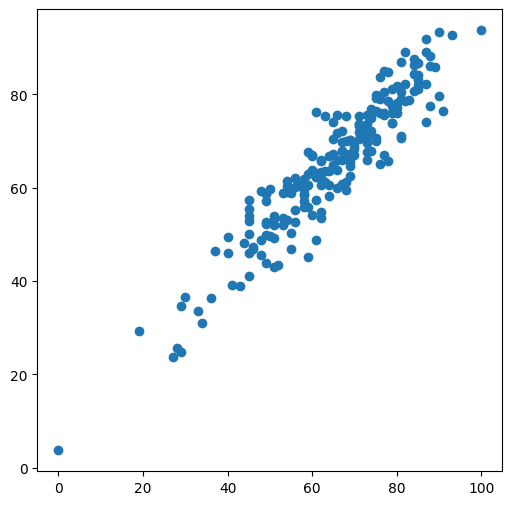

In [115]:
plt.figure(figsize=(6,6))
plt.scatter(ytest,ypred)
plt.show()

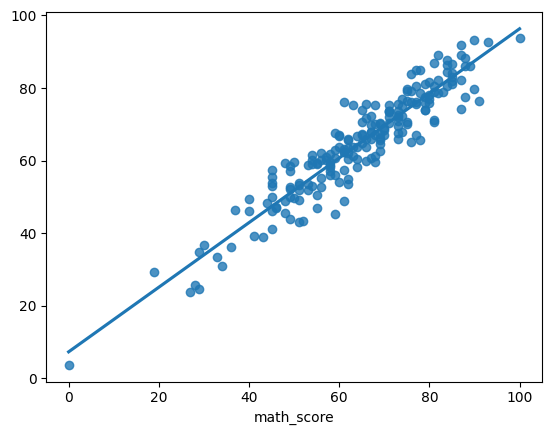

In [122]:
sns.regplot(x=ytest,y=ypred,ci=None);